In [3]:
# Import necessary libraries
import os
from datetime import datetime

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")



TensorFlow version: 2.17.1
Keras version: 3.5.0
GPU devices: 2


In [4]:

import SimpleITK as sitk
import cv2  # For resizing

# Load the dataset
data = pd.read_excel('/kaggle/input/targets/dataset_lung.xlsx')
image_folder_path = '/kaggle/input/images/Train'

X_full, X_nodule, Y_class, Y_binary = [], [], [], []

# Define target size for resizing
target_size = (224, 224)

for idx, row in data.iterrows():
    full_slice_filename = row['Full_slice']
    nodule_filename = row['Nodule']
    tumor_class = row['TumorClass']
    
    # Load full slice and nodule images
    try:
        full_slice_path = os.path.join(image_folder_path, full_slice_filename)
        nodule_path = os.path.join(image_folder_path, nodule_filename)
        
        # Read images using SimpleITK
        full_slice_image = sitk.GetArrayFromImage(sitk.ReadImage(full_slice_path))
        nodule_image = sitk.GetArrayFromImage(sitk.ReadImage(nodule_path))
        
        # Resize images
        full_slice_resized = cv2.resize(full_slice_image, target_size)
        nodule_resized = cv2.resize(nodule_image, target_size)
        
        # Normalize pixel values independently for each image
        # Convert to float32 before scaling to avoid overflow
        full_slice_resized = full_slice_resized.astype(np.float32)
        nodule_resized = nodule_resized.astype(np.float32)

        '''
        # Now normalize the images to [0, 255] independently
        full_slice_resized = ((full_slice_resized - full_slice_resized.min()) / 
                              (full_slice_resized.max() - full_slice_resized.min()) * 1.0).astype(np.float32)
        nodule_resized = ((nodule_resized - nodule_resized.min()) / 
                          (nodule_resized.max() - nodule_resized.min()) * 1.0).astype(np.float32)
        '''
        # Append to lists
        X_full.append(full_slice_resized)
        X_nodule.append(nodule_resized)
        Y_class.append(tumor_class)
        Y_binary.append(0 if tumor_class <= 3 else 1)
    
    except Exception as e:
        print(f"Error loading or processing image: {full_slice_filename} or {nodule_filename} - {e}")

# Convert lists to NumPy arrays
X_full = np.array(X_full)
X_nodule = np.array(X_nodule)
Y_class = np.array(Y_class)
Y_binary = np.array(Y_binary)

# Add a channel dimension for grayscale images
X_full = np.expand_dims(X_full, axis=-1)  # Shape becomes (2363, 224, 224, 1)
X_nodule = np.expand_dims(X_nodule, axis=-1)  # Shape becomes (2363, 224, 224, 1)

# Ensure labels are properly shaped
Y_class = Y_class.reshape(-1, 1)  # Shape becomes (2363, 1)
Y_binary = Y_binary.reshape(-1, 1)  # Shape becomes (2363, 1)

# Print shapes for verification
print(X_full.shape, X_nodule.shape, Y_class.shape, Y_binary.shape)


(2363, 224, 224, 1) (2363, 224, 224, 1) (2363, 1) (2363, 1)


In [5]:

def visualize_examples(X_full, X_nodule, Y_class, class_names=None, num_examples=1):
    """
    Visualize examples for each tumor class.
    
    Parameters:
        X_full (np.array): Full slice images.
        X_nodule (np.array): Nodule images.
        Y_class (np.array): Tumor classes.
        class_names (list): Optional, names of classes (e.g., ["1", "2", "3", "4", "5"]).
        num_examples (int): Number of examples to display per class.
    """
    unique_classes = np.unique(Y_class)  # Find all unique classes
    class_names = class_names or [str(c) for c in unique_classes]
    
    plt.figure(figsize=(15, len(unique_classes) * 3))
    
    for i, class_label in enumerate(unique_classes):
        class_indices = np.where(Y_class == class_label)[0]  # Find indices of this class
        selected_indices = np.random.choice(class_indices, size=num_examples, replace=False)
        
        for j, idx in enumerate(selected_indices):
            # Plot full slice
            plt.subplot(len(unique_classes), 2 * num_examples, i * 2 * num_examples + j + 1)
            plt.imshow(X_full[idx], cmap='gray')
            plt.title(f"Class {class_names[i]} - Full Slice")
            plt.axis('off')
            
            # Plot nodule
            plt.subplot(len(unique_classes), 2 * num_examples, i * 2 * num_examples + num_examples + j + 1)
            plt.imshow(X_nodule[idx], cmap='gray')
            plt.title(f"Class {class_names[i]} - Nodule")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_class_distribution(Y_class, Y_binary):
    """
    Plot the distribution of tumor classes and benign/malignant labels.
    
    Parameters:
        Y_class (np.array): Tumor class labels (1-5).
        Y_binary (np.array): Binary labels (0 for benign, 1 for malignant).
    """
    # Tumor class distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    class_counts = np.unique(Y_class, return_counts=True)
    plt.bar(class_counts[0], class_counts[1], color='skyblue', edgecolor='black')
    plt.xlabel('Tumor Class')
    plt.ylabel('Frequency')
    plt.title('Tumor Class Distribution')
    plt.xticks(class_counts[0])
    
    # Binary class distribution (Benign vs Malignant)
    plt.subplot(1, 2, 2)
    binary_counts = np.unique(Y_binary, return_counts=True)
    plt.bar(['Benign (0)', 'Malignant (1)'], binary_counts[1], color=['green', 'red'], edgecolor='black')
    plt.ylabel('Frequency')
    plt.title('Benign vs Malignant Distribution')
    
    plt.tight_layout()
    plt.show()


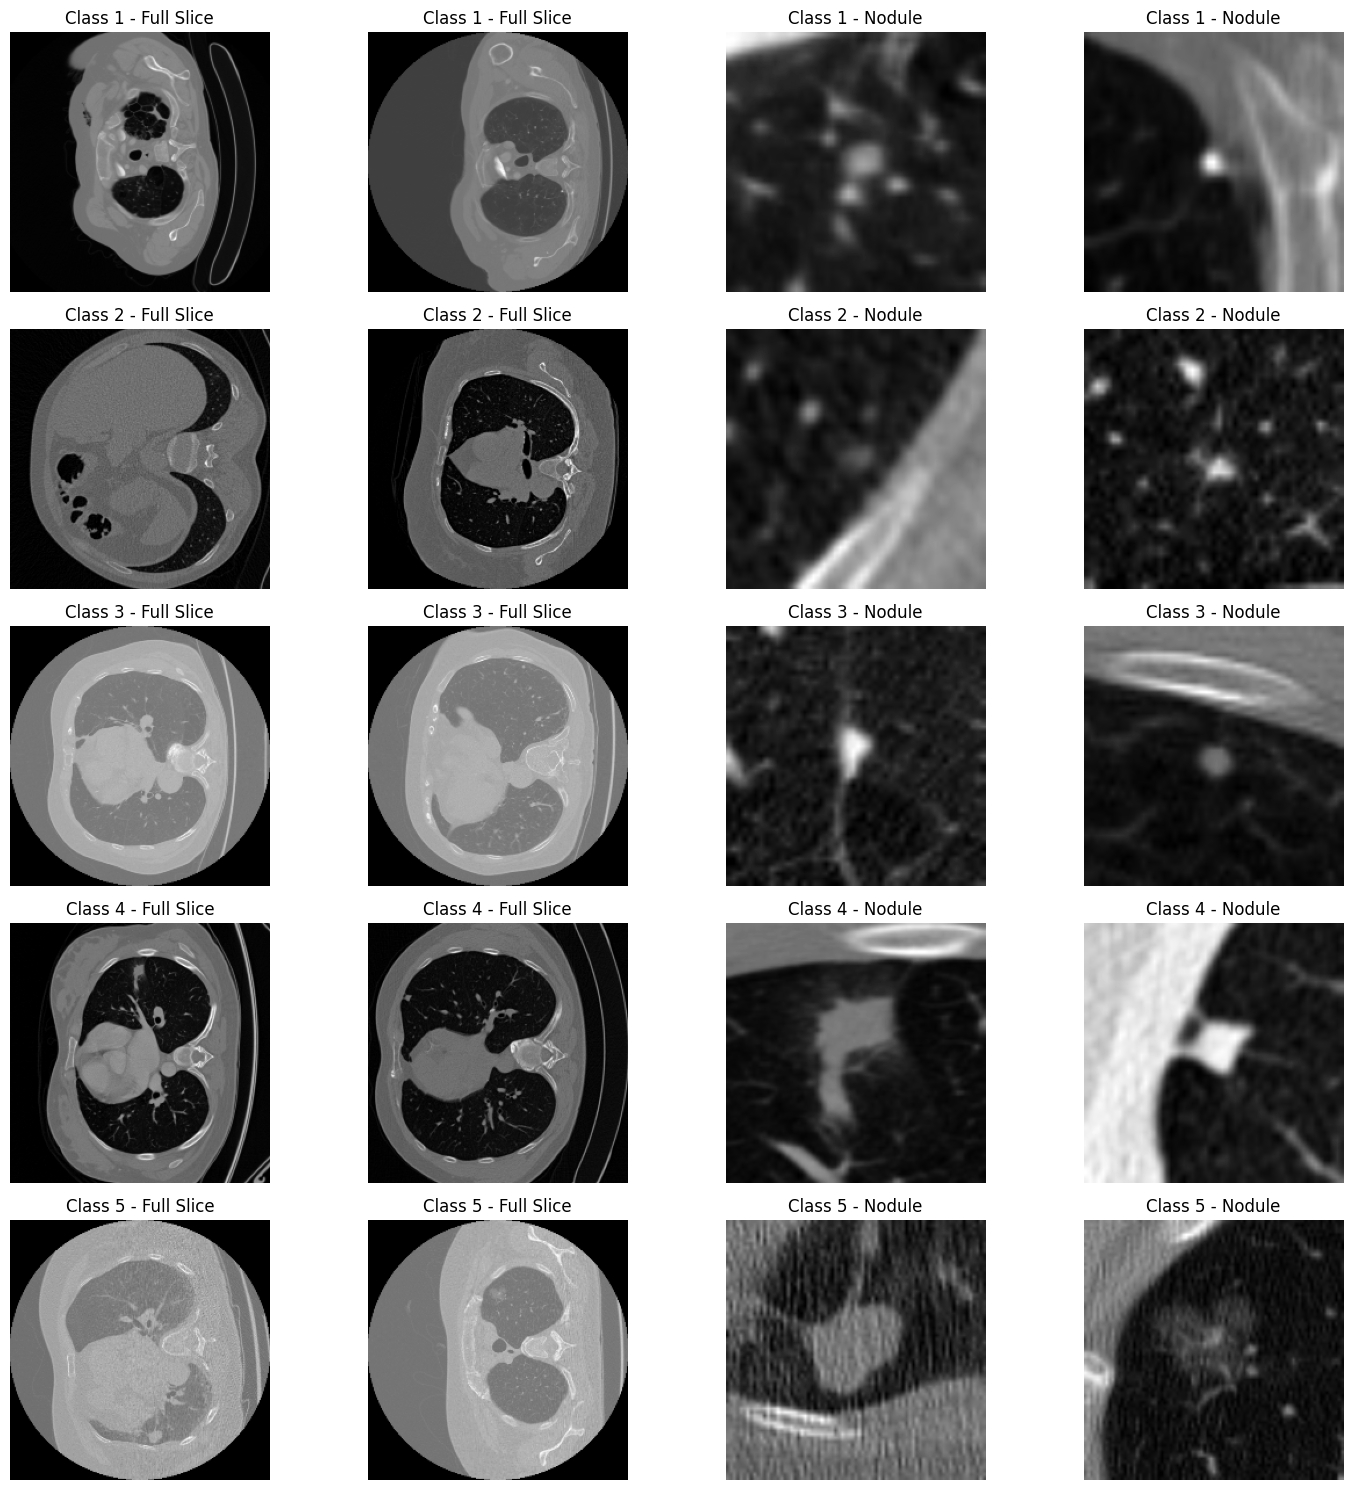

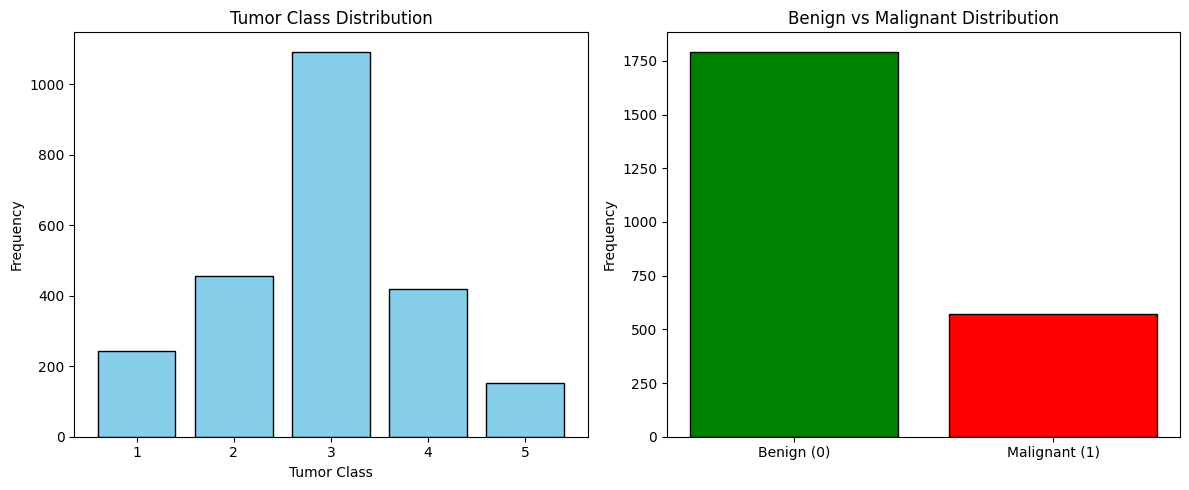

In [6]:
# Visualize examples
visualize_examples(X_full, X_nodule, Y_class, class_names=["1", "2", "3", "4", "5"], num_examples=2)

# Plot class distributions
plot_class_distribution(Y_class, Y_binary)


In [7]:
Y_class = Y_class - 1

In [8]:
def calculate_class_weights(Y_class, Y_binary):
    """
    Calculate and normalize class weights for multi-class (0-4) and binary labels (0-1).
    Normalization ensures the weights sum to 1.
    
    Parameters:
        Y_class (np.array): Tumor class labels (0-4).
        Y_binary (np.array): Binary labels (0 for benign, 1 for malignant).
    
    Returns:
        dict: Normalized weights for each class in 0-4.
        dict: Normalized weights for binary labels (0 and 1).
    """
    from collections import Counter
    
    # Multi-class weights
    class_counts = Counter(Y_class.flatten())  # Count occurrences of each class
    total_samples = len(Y_class)  # Total number of samples
    class_weights = {cls: total_samples / count for cls, count in class_counts.items()}
    # Normalize weights to sum to 1
    total_class_weight = sum(class_weights.values())
    class_weights = {cls: weight / total_class_weight for cls, weight in class_weights.items()}
    
    # Binary weights
    binary_counts = Counter(Y_binary.flatten())  # Count occurrences of each binary class
    binary_weights = {cls: total_samples / count for cls, count in binary_counts.items()}
    # Normalize weights to sum to 1
    total_binary_weight = sum(binary_weights.values())
    binary_weights = {cls: weight / total_binary_weight for cls, weight in binary_weights.items()}
    
    return class_weights, binary_weights

# Example usage with zero-indexed classes
class_weights, binary_weights = calculate_class_weights(Y_class, Y_binary)

# Print results
print("Normalized Class Weights (0-4):", class_weights)
print("Normalized Binary Weights (0-1):", binary_weights)


Normalized Class Weights (0-4): {4: 0.40677106870476964, 1: 0.13529365961296497, 3: 0.14791675225627987, 2: 0.05662014875744046, 0: 0.25339837066854504}
Normalized Binary Weights (0-1): {1: 0.758781210325857, 0: 0.241218789674143}


In [9]:

def split_data(X_full, X_nodule, Y_class, Y_binary, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_state=42):
    """
    Split data into training, validation, and test sets with stratification.
    
    Parameters:
        X_full (np.array): Full slice images.
        X_nodule (np.array): Nodule images.
        Y_class (np.array): Tumor class labels (1-5).
        Y_binary (np.array): Binary labels (0-1).
        train_ratio (float): Proportion of data for training (default 0.8).
        val_ratio (float): Proportion of data for validation (default 0.1).
        test_ratio (float): Proportion of data for testing (default 0.1).
        random_state (int): Random seed for reproducibility.
    
    Returns:
        dict: Split datasets for X_full, X_nodule, Y_class, and Y_binary.
    """
    # First split into train and temp (validation + test)
    X_full_train, X_full_temp, X_nodule_train, X_nodule_temp, Y_class_train, Y_class_temp, Y_binary_train, Y_binary_temp = train_test_split(
        X_full, X_nodule, Y_class, Y_binary,
        test_size=(val_ratio + test_ratio),
        stratify=Y_class,
        random_state=random_state
    )
    
    # Split the temp set into validation and test
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)  # Adjust validation ratio
    X_full_val, X_full_test, X_nodule_val, X_nodule_test, Y_class_val, Y_class_test, Y_binary_val, Y_binary_test = train_test_split(
        X_full_temp, X_nodule_temp, Y_class_temp, Y_binary_temp,
        test_size=(1 - val_ratio_adjusted),
        stratify=Y_class_temp,
        random_state=random_state
    )
    
    return {
        "X_full_train": X_full_train, "X_full_val": X_full_val, "X_full_test": X_full_test,
        "X_nodule_train": X_nodule_train, "X_nodule_val": X_nodule_val, "X_nodule_test": X_nodule_test,
        "Y_class_train": Y_class_train, "Y_class_val": Y_class_val, "Y_class_test": Y_class_test,
        "Y_binary_train": Y_binary_train, "Y_binary_val": Y_binary_val, "Y_binary_test": Y_binary_test
    }

# Example usage
split_data_dict = split_data(X_full, X_nodule, Y_class, Y_binary)

# Access splits
X_full_train = split_data_dict["X_full_train"]
X_full_val = split_data_dict["X_full_val"]
X_full_test = split_data_dict["X_full_test"]

X_nodule_train = split_data_dict["X_nodule_train"]
X_nodule_val = split_data_dict["X_nodule_val"]
X_nodule_test = split_data_dict["X_nodule_test"]

Y_class_train = split_data_dict["Y_class_train"]
Y_class_val = split_data_dict["Y_class_val"]
Y_class_test = split_data_dict["Y_class_test"]

Y_binary_train = split_data_dict["Y_binary_train"]
Y_binary_val = split_data_dict["Y_binary_val"]
Y_binary_test = split_data_dict["Y_binary_test"]

# Print sizes for verification
print(f"Train size: {len(Y_class_train)}, Validation size: {len(Y_class_val)}, Test size: {len(Y_class_test)}")


Train size: 1890, Validation size: 236, Test size: 237


In [10]:
import numpy as np

def convert_to_rgb(X):
    # Ensure the input has a single channel (shape: (n_samples, height, width, 1))
    if X.ndim == 3:  # Handle the case if there is no channel dimension
        X = X[..., np.newaxis]
    # Replicate the grayscale image across 3 channels to create an RGB image
    X_rgb = np.repeat(X, 3, axis=-1)  # This replicates the grayscale image across 3 channels
    return X_rgb

X_full_train = convert_to_rgb(X_full_train)
X_full_val = convert_to_rgb(X_full_val)
X_full_test = convert_to_rgb(X_full_test)

X_nodule_train = convert_to_rgb(X_nodule_train)
X_nodule_val = convert_to_rgb(X_nodule_val)
X_nodule_test = convert_to_rgb(X_nodule_test)

# Print shape of the new arrays
print(f"X_full_rgb shape: {X_full_train.shape}")
print(f"X_nodule_rgb shape: {X_nodule_train.shape}")


X_full_rgb shape: (1890, 224, 224, 3)
X_nodule_rgb shape: (1890, 224, 224, 3)


In [11]:
import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
def multiclass_model(input_shape=(224, 224, 3), num_classes=None):
   
    # Load the EfficientNetV2B0 model pre-trained on ImageNet, excluding the top classification layer
    efficientNet = tfk.applications.MobileNetV2(
        input_shape=(224, 224, 3),  # Updated to have 3 channels
        include_top=False,
        weights='imagenet',
        pooling='avg',
        #include_preprocessing=True
    )
    efficientNet.trainable = False  # Freeze the EfficientNetV2B0 layers

    # Build the feature extraction pipeline using the pre-trained EfficientNetV2B0 model
    inputs = tfk.Input(shape=input_shape, name='input_layer')

    inputs = preprocess_input(inputs)
    
    # Pass through EfficientNetV2B0 model
    x = efficientNet(inputs)

    # Add dropout for regularization
    x = tfkl.Dropout(0.3, seed=42)(x)

    # Add batch normalization for stabilizing training
    x = tfkl.BatchNormalization()(x)

    # Add dense layers with ReLU activation
    x = tfkl.Dense(512, activation='relu', name='dense_1', kernel_initializer=tfk.initializers.HeUniform(42))(x)
    x = tfkl.Dropout(0.3, seed=42)(x)
    x = tfkl.BatchNormalization()(x)
    x = tfkl.Dense(256, activation='relu', name='dense_2', kernel_initializer=tfk.initializers.HeUniform(42))(x)
    x = tfkl.Dropout(0.2, seed=42)(x)
    x = tfkl.BatchNormalization()(x)

    # Final output layer with softmax activation for multi-class classification
    outputs = tfkl.Dense(num_classes, activation='softmax', name='dense_3', kernel_initializer=tfk.initializers.GlorotUniform(42))(x)

    # Create the model
    model = tfk.Model(inputs=inputs, outputs=outputs, name='full_slice_multiclass_model')

    return model




In [13]:
nodule_multiclass_model = multiclass_model(input_shape=(224, 224, 3), num_classes= 5)
nodule_multiclass_model.summary()

Model: "full_slice_multiclass_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ keras_tensor_323CLONE (InputLayer)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,054,661 (11.65 MB)

 Trainable params: 792,581 (3.02 MB)

 Non-trainable params: 2,262,080 (8.63 MB)

In [14]:
optimizer = tfk.optimizers.Adam(1e-4)
nodule_multiclass_model.compile(loss=tfk.losses.SparseCategoricalCrossentropy(), optimizer=optimizer, metrics=['accuracy'])


In [15]:


tl_nodule_multiclass_model_history = nodule_multiclass_model.fit(
    X_nodule_train,  # Input data for training (converted to RGB)
    Y_class_train,     # Target labels for training
    validation_data=(X_nodule_val, Y_class_val),  # Validation data and labels
    epochs=200,
    class_weight=class_weights,  # Class weights for handling imbalanced data
    callbacks=[
        tfk.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=15, restore_best_weights=True)
    ]
).history


# Calculate and print the best validation accuracy achieved
final_val_accuracy = round(max(tl_nodule_multiclass_model_history['val_accuracy']) * 100, 2)
print(f'Final validation accuracy: {final_val_accuracy}%')

# Save the trained model to a file, including final accuracy in the filename
model_filename = 'MCNfrozen' + str(final_val_accuracy) + '.keras'
nodule_multiclass_model.save(model_filename)

del nodule_multiclass_model

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 224ms/step - accuracy: 0.2095 - loss: 0.2873 - val_accuracy: 0.2500 - val_loss: 1.5596
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.2684 - loss: 0.2305 - val_accuracy: 0.3136 - val_loss: 1.5148
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2783 - loss: 0.2166 - val_accuracy: 0.3347 - val_loss: 1.4712
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2986 - loss: 0.2098 - val_accuracy: 0.3517 - val_loss: 1.4490
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3309 - loss: 0.1979 - val_accuracy: 0.3771 - val_loss: 1.4437
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3739 - loss: 0.1891 - val_accuracy: 0.3686 - val_loss: 1.4388
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3624 - loss: 0.1810 - val_accuracy: 0.3644 - val_loss: 1.4364
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3671 - loss: 0.1802 - val_accuracy: 

In [16]:
# Re-load the model after transfer learning
ft_model = tfk.models.load_model('MCNfrozen39.41.keras')

# Display a summary of the model architecture
ft_model.summary(expand_nested=True)

# Display model architecture with layer shapes and trainable parameters
#tfk.utils.plot_model(ft_model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

# Set the MobileNetV3Small model layers as trainable
ft_model.get_layer('mobilenetv2_1.00_224').trainable = True

# Set all MobileNetV3Small layers as non-trainable
for layer in ft_model.get_layer('mobilenetv2_1.00_224').layers:
    layer.trainable = False

# Enable training only for Conv2D and DepthwiseConv2D layers
for i, layer in enumerate(ft_model.get_layer('mobilenetv2_1.00_224').layers):
    if isinstance(layer, tf.keras.layers.Conv2D) or isinstance(layer, tf.keras.layers.DepthwiseConv2D):
        layer.trainable = True
        print(i, layer.name, type(layer).__name__, layer.trainable)

# Set the number of layers to freeze
N = 150

# Set the first N layers as non-trainable
for i, layer in enumerate(ft_model.get_layer('mobilenetv2_1.00_224').layers[:N]):
    layer.trainable = False

# Print layer indices, names, and trainability status
for i, layer in enumerate(ft_model.get_layer('mobilenetv2_1.00_224').layers):
    print(i, layer.name, layer.trainable)

# Display a summary of the model architecture
ft_model.summary(expand_nested=True)

# Display model architecture with layer shapes and trainable parameters
#tfk.utils.plot_model(ft_model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

Model: "full_slice_multiclass_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ keras_tensor_323CLONE (InputLayer)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ Conv1 (Conv2D)                  │ (None, 112, 112, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ bn_Conv1 (BatchNormalization)   │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ Conv1_relu (ReLU)               │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_depthwise         │ (None, 112, 112, 32)        │             288 │
│ (DepthwiseConv2D)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_depthwise_BN      │ (None, 112, 112, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_depthwise_relu    │ (None, 112, 112, 32)        │               0 │
│ (ReLU)                               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_project (Conv2D)  │ (None, 112, 112, 16)        │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_project_BN        │ (None, 112, 112, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_expand (Conv2D)         │ (None, 112, 112, 96)        │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_expand_BN               │ (None, 112, 112, 96)        │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_expand_relu (ReLU)      │ (None, 112, 112, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_pad (ZeroPadding2D)     │ (None, 113, 113, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_depthwise               │ (None, 56, 56, 96)          │             864 │
│ (DepthwiseConv2D)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_depthwise_BN            │ (None, 56, 56, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_depthwise_relu (ReLU)   │ (None, 56, 56, 96)          │              

 Total params: 4,639,825 (17.70 MB)

 Trainable params: 792,581 (3.02 MB)

 Non-trainable params: 2,262,080 (8.63 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ keras_tensor_323CLONE (InputLayer)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ Conv1 (Conv2D)                  │ (None, 112, 112, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ bn_Conv1 (BatchNormalization)   │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ Conv1_relu (ReLU)               │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_depthwise         │ (None, 112, 112, 32)        │             288 │
│ (DepthwiseConv2D)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_depthwise_BN      │ (None, 112, 112, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_depthwise_relu    │ (None, 112, 112, 32)        │               0 │
│ (ReLU)                               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_project (Conv2D)  │ (None, 112, 112, 16)        │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ expanded_conv_project_BN        │ (None, 112, 112, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_expand (Conv2D)         │ (None, 112, 112, 96)        │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_expand_BN               │ (None, 112, 112, 96)        │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_expand_relu (ReLU)      │ (None, 112, 112, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_pad (ZeroPadding2D)     │ (None, 113, 113, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_depthwise               │ (None, 56, 56, 96)          │             864 │
│ (DepthwiseConv2D)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_depthwise_BN            │ (None, 56, 56, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ block_1_depthwise_relu (ReLU)   │ (None, 56, 56, 96)          │              

 Total params: 4,639,825 (17.70 MB)

 Trainable params: 1,202,181 (4.59 MB)

 Non-trainable params: 1,852,480 (7.07 MB)

 Optimizer params: 1,585,164 (6.05 MB)

In [17]:
optimizer = tfk.optimizers.RMSprop(1e-4)
ft_model.compile(loss=tfk.losses.SparseCategoricalCrossentropy(), optimizer=optimizer, metrics=['accuracy'])


In [18]:
ft_model_history = ft_model.fit(
    X_nodule_train,  # Input data for training (converted to RGB)
    Y_class_train,     # Target labels for training
    validation_data=(X_nodule_val, Y_class_val),  # Validation data and labels
    epochs=200,
    class_weight=class_weights,  # Class weights for handling imbalanced data
    callbacks=[
        tfk.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=20, restore_best_weights=True)
    ]
).history


# Calculate and print the best validation accuracy achieved
final_val_accuracy = round(max(ft_model_history['val_accuracy']) * 100, 2)
print(f'Final validation accuracy: {final_val_accuracy}%')

# Save the trained model to a file, including final accuracy in the filename
model_filename = 'final' + str(final_val_accuracy) + '.keras'
ft_model.save(model_filename)

del ft_model

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.5338 - loss: 0.1169 - val_accuracy: 0.3983 - val_loss: 1.3954
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5213 - loss: 0.1189 - val_accuracy: 0.4025 - val_loss: 1.4036
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5292 - loss: 0.1150 - val_accuracy: 0.4068 - val_loss: 1.3940
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5410 - loss: 0.1177 - val_accuracy: 0.4237 - val_loss: 1.3659
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5504 - loss: 0.1105 - val_accuracy: 0.4364 - val_loss: 1.3623
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6062 - loss: 0.1024 - val_accuracy: 0.4322 - val_loss: 1.3629
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6186 - loss: 0.0975 - val_accuracy: 0.4280 - val_loss: 1.4072
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5926 - loss: 0.0998 - val_accuracy: 

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 611ms/step
Accuracy: 0.4599
Precision: 0.4532
Recall: 0.4599
F1-score: 0.4519

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.33      0.41        24
           1       0.33      0.30      0.31        46
           2       0.55      0.64      0.59       110
           3       0.35      0.29      0.32        42
           4       0.28      0.33      0.30        15

    accuracy                           0.46       237
   macro avg       0.41      0.38      0.39       237
weighted avg       0.45      0.46      0.45       237



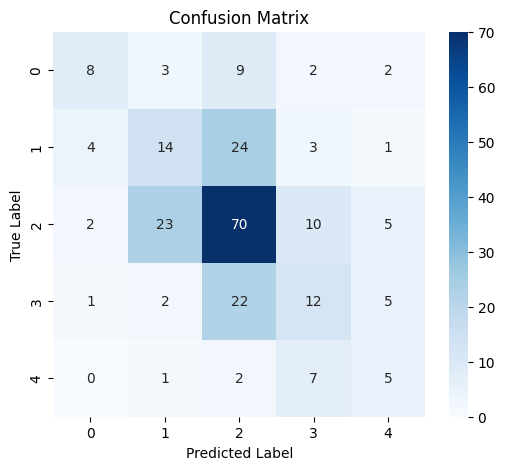

In [19]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, Y_test, binary_classification=True):
    """
    Evaluates a trained model and prints various performance scores.
    
    Parameters:
        model: Trained TensorFlow/Keras model
        X_test: Test set features (NumPy array)
        Y_test: Test set labels (NumPy array)
        binary_classification: Whether the problem is binary classification (default=True)
    
    Returns:
        None (Prints metrics and plots the confusion matrix)
    """
    
    # Get model predictions
    Y_pred_probs = model.predict(X_test)  # Probabilities

    # Convert probabilities to class labels
    if binary_classification:
        Y_pred = (Y_pred_probs >= 0.5).astype(int)  # Threshold at 0.5
    else:
        Y_pred = np.argmax(Y_pred_probs, axis=1)
        #Y_test = np.argmax(Y_test, axis=1)  # Convert one-hot to label indices if needed

    # Compute performance metrics
    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred, average="binary" if binary_classification else "weighted")
    recall = recall_score(Y_test, Y_pred, average="binary" if binary_classification else "weighted")
    f1 = f1_score(Y_test, Y_pred, average="binary" if binary_classification else "weighted")
    roc_auc = roc_auc_score(Y_test, Y_pred_probs) if binary_classification else None  # ROC AUC only for binary
    
    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    if binary_classification:
        print(f"ROC-AUC: {roc_auc:.4f}")

    # Print classification report
    print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

    # Compute and plot confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Example usage:
# Assuming `trained_model` is your trained model and X_test, Y_test are your test dataset
model = tfk.models.load_model('final49.15.keras')

evaluate_model(model, X_nodule_test, Y_class_test, binary_classification=False)
